# 04 — Filtrations

A **filtration** is a way of building a topological space, or a simplicial complex, step by step.

In the previous notebooks we developed three ingredients:

- metric spaces, which give us distances between data points;
- simplicial complexes, which turn combinatorial data into topological spaces;
- homology, which detects holes in those spaces.

The next question is:

> What if the simplicial complex itself depends on a scale parameter?

This is the central idea of a **filtration** in TDA (although, the overall philosophy is same when it appears in `Singularity Theory`).

We will begin with finite simplicial complexes and then connect filtrations to metric data. The emphasis is on understanding the construction before introducing persistent homology.

Throughout this notebook, we work over the field

$$
\mathbb{F}_2 = \{0,1\}.
$$

## Learning goals

By the end of this notebook, you should be able to:

1. define a filtration of a simplicial complex;
2. check whether a sequence of complexes is a filtration;
3. construct filtrations by assigning values to simplices;
4. understand lower-star filtrations;
5. visualize a filtration as a sequence of growing complexes;
6. construct a Vietoris–Rips filtration from a finite metric space;
7. understand why filtrations are the natural input for persistent homology.

We will repeatedly use the same philosophy:

> **Definition → example → non-example → computation → visualization → exercise.**

## 1. What is a filtration?

Let

$$
K_0,K_1,\ldots,K_m
$$

be simplicial complexes.

We call this sequence a **filtration** if

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m.
$$

Thus, as the filtration parameter increases, simplices may be **added**, but never removed.

It is useful to imagine a movie:

- at the beginning, we see only a few vertices;
- then edges appear;
- then higher-dimensional simplices appear;
- the topology changes as the complex grows.

A filtration records this entire movie as a sequence of mathematical objects.

### Example: adding the edges of a triangle

Consider the triangle with vertices

$$
V=\{0,1,2\}.
$$

We can define

$$
K_0=\{\{0\},\{1\},\{2\}\},
$$

$$
K_1=K_0\cup\{\{0,1\}\},
$$

$$
K_2=K_1\cup\{\{1,2\}\},
$$

and

$$
K_3=K_2\cup\{\{0,2\}\}.
$$

Then

$$
K_0\subseteq K_1\subseteq K_2\subseteq K_3.
$$

Therefore this is a filtration.

Notice something important: at no stage do we add an edge without already having its two endpoints.

### Non-example

Consider

$$
K_0=\{\{0\},\{1\},\{2\}\},
$$

and

$$
K_1=K_0\cup\{\{0,1\}\}.
$$

Now suppose that

$$
K_2=K_1\setminus\{\{0,1\}\}.
$$

Then

$$
K_2\not\supseteq K_1.
$$

A simplex has disappeared, so this sequence is **not** a filtration.

There is a second possible failure: even if the complexes are nested, one of them might not itself be a simplicial complex. For example, adding an edge without its vertices violates the closure condition.

## 2. A filtration as a function

Instead of writing a sequence, it is often convenient to think of a filtration as a one-parameter family

$$
K(t).
$$

The parameter $t$ represents a scale or threshold.

For a finite filtration, we might have

$$
K(t_0)\subseteq K(t_1)\subseteq\cdots\subseteq K(t_m),
\qquad
t_0<t_1<\cdots<t_m.
$$

The notation

$$
K(s)\subseteq K(t)
$$

whenever

$$
s\leq t
$$

captures the essential idea.

Later, persistent homology will study how homology changes as $t$ varies.

## 3. Filtrations from a function on simplices

A useful way to construct a filtration is to assign a number to every simplex.

Let

$$
f:K\to\mathbb{R}
$$

be a function on the simplices of a simplicial complex $K$.

For each threshold $t$, define

$$
K_t=\{\sigma\in K:f(\sigma)\leq t\}.
$$

For this to be a simplicial complex, we need

$$
\tau\subseteq\sigma
\quad\Longrightarrow\quad
f(\tau)\leq f(\sigma).
$$

In words:

> **Faces must appear no later than the simplices containing them.**

Such a function is often called a **filtration function**.

### Example: a filtration function on a triangle

Take the filled triangle

$$
K=\{0,1,2,01,12,02,012\}.
$$

Assign values

$$
f(0)=f(1)=f(2)=0,
$$

$$
f(01)=1,\qquad f(12)=2,\qquad f(02)=3,
$$

and

$$
f(012)=4.
$$

Then the threshold complexes are

$$
K_0=\{0,1,2\},
$$

$$
K_1=K_0\cup\{01\},
$$

$$
K_2=K_1\cup\{12\},
$$

$$
K_3=K_2\cup\{02\},
$$

and

$$
K_4=K_3\cup\{012\}.
$$

This gives a filtration.

The numbers attached to simplices tell us **when each simplex enters the construction**.

### Non-example: a face appearing too late

Suppose instead that

$$
f(0)=5
$$

but

$$
f(01)=1.
$$

Then at threshold $t=1$, the edge $01$ has appeared but vertex $0$ has not.

That violates the simplicial-complex condition.

Thus an arbitrary function on simplices does **not** automatically define a filtration.

## 4. Checking a filtration computationally

We represent a simplex by a tuple of vertices:

- `(0,)` is a vertex;
- `(0, 1)` is an edge;
- `(0, 1, 2)` is a triangle.

A simplicial complex is represented by a set of such tuples.

### Pseudocode

```text
FUNCTION is_filtration(sequence):
    FOR each consecutive pair (K_i, K_{i+1}):
        IF K_i is not a subset of K_{i+1}:
            RETURN False
    RETURN True
```

In [1]:
def is_filtration(sequence):
    return all(
        sequence[i].issubset(sequence[i + 1])
        for i in range(len(sequence) - 1)
    )


K0 = {(0,), (1,), (2,)}
K1 = K0 | {(0, 1)}
K2 = K1 | {(1, 2)}
K3 = K2 | {(0, 2)}

filtration = [K0, K1, K2, K3]

print(is_filtration(filtration))

True


The result should be `True`.

But nesting is only part of the story. We also want every stage to be a valid simplicial complex.

### Checking the simplicial-complex condition

Recall from Notebook 02:

$$
\sigma\in K,\ \tau\subseteq\sigma
\quad\Longrightarrow\quad
\tau\in K.
$$

We can therefore write a small checker for finite complexes.

### Pseudocode

```text
FUNCTION is_simplicial_complex(K):
    FOR every simplex sigma in K:
        FOR every face tau of sigma:
            IF tau is not in K:
                RETURN False
    RETURN True
```

In [2]:
from itertools import combinations


def all_faces(simplex):
    simplex = tuple(sorted(simplex))
    faces = set()

    for r in range(1, len(simplex) + 1):
        for face in combinations(simplex, r):
            faces.add(face)

    return faces


def is_simplicial_complex(K):
    K = {tuple(sorted(sigma)) for sigma in K}

    for sigma in K:
        if not all(face in K for face in all_faces(sigma)):
            return False

    return True


print(is_simplicial_complex(K3))

True


## 5. Visualizing a filtration

A filtration is particularly easy to understand when we draw its stages.

We will use a triangle whose edges appear one at a time.

### Pseudocode

```text
Create three vertices at fixed coordinates.

For each stage:
    draw the vertices
    draw all edges present at that stage
    label the stage
Display the stages side by side.
```

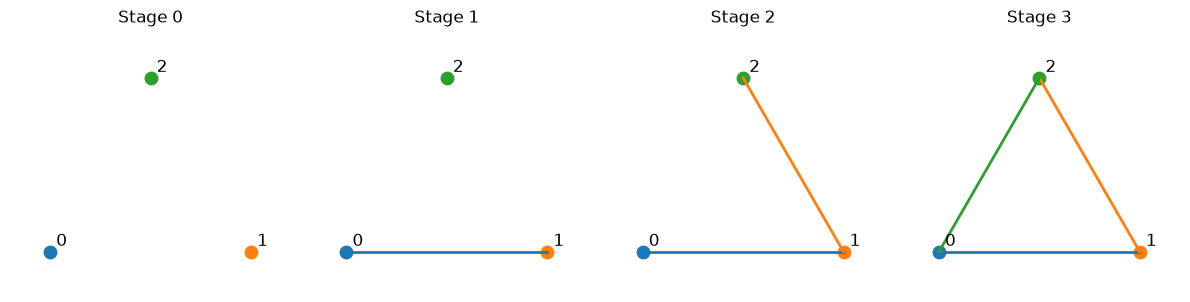

In [3]:
import matplotlib.pyplot as plt

points = {
    0: (0, 0),
    1: (1, 0),
    2: (0.5, 0.866)
}

stages = [
    [],
    [(0, 1)],
    [(0, 1), (1, 2)],
    [(0, 1), (1, 2), (0, 2)]
]

fig, axes = plt.subplots(1, len(stages), figsize=(12, 3))

for i, (ax, edges) in enumerate(zip(axes, stages)):
    for u, v in edges:
        ax.plot(
            [points[u][0], points[v][0]],
            [points[u][1], points[v][1]],
            linewidth=2
        )

    for vertex, (x, y) in points.items():
        ax.scatter(x, y, s=80)
        ax.text(x + 0.03, y + 0.03, str(vertex), fontsize=12)

    ax.set_title(f"Stage {i}")
    ax.set_aspect("equal")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.1)
    ax.axis("off")

plt.tight_layout()
plt.show()

The picture makes the nesting condition almost immediate:

$$
K_0\subseteq K_1\subseteq K_2\subseteq K_3.
$$

This is one reason visualization is useful in TDA: the parameter is not merely a number. It describes a changing geometric object.

## 6. What changes topologically during a filtration?

Consider the same triangle, but continue one step further by adding the filled 2-simplex.

The stages are:

$$
\text{three vertices}
\longrightarrow
\text{three edges forming a loop}
\longrightarrow
\text{filled triangle}.
$$

At the stage where all three edges are present but the interior is absent, there is a 1-dimensional hole:

$$
\beta_1=1.
$$

After the triangle is filled, the hole disappears:

$$
\beta_1=0.
$$

This is the basic phenomenon that persistent homology will record.

For now, the important point is:

> **A filtration lets us watch topological features appear and disappear as the parameter changes.**

### Visualizing the filled triangle stage

### Pseudocode

```text
Draw the three vertices.
Draw all three boundary edges.
Draw the triangular face as a filled region.
Compare this with the previous stage.
```

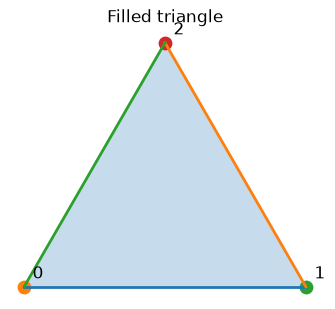

In [4]:
triangle_vertices = {
    0: (0, 0),
    1: (1, 0),
    2: (0.5, 0.866)
}

fig, ax = plt.subplots(figsize=(4, 4))

polygon_x = [0, 1, 0.5, 0]
polygon_y = [0, 0, 0.866, 0]

ax.fill(polygon_x, polygon_y, alpha=0.25)

for u, v in [(0, 1), (1, 2), (0, 2)]:
    ax.plot(
        [triangle_vertices[u][0], triangle_vertices[v][0]],
        [triangle_vertices[u][1], triangle_vertices[v][1]],
        linewidth=2
    )

for vertex, (x, y) in triangle_vertices.items():
    ax.scatter(x, y, s=80)
    ax.text(x + 0.03, y + 0.03, str(vertex), fontsize=12)

ax.set_title("Filled triangle")
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## 7. Filtrations and homology

Suppose

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m
$$

is a filtration.

Each inclusion induces maps on homology:

(This is because homology is a functor, but don't worry if you don't understand this term. For now, just take it for a fact.)

$$
H_k(K_0)\longrightarrow H_k(K_1)
\longrightarrow\cdots\longrightarrow
H_k(K_m).
$$

For example, a 1-dimensional hole can:

- not yet exist;
- appear;
- remain present for several stages;
- eventually disappear when it becomes filled.

This leads naturally to the language of **birth** and **death**.

We will study that systematically in the next notebook on persistent homology.

## 8. Lower-star filtrations

Suppose a function

$$
g:V(K)\to\mathbb{R}
$$

is defined only on the vertices of a simplicial complex.

For each simplex

$$
\sigma=\{v_0,\ldots,v_k\},
$$

define its filtration value by

$$
f(\sigma)=\max_{v\in\sigma}g(v).
$$

Then

$$
\tau\subseteq\sigma
\quad\Longrightarrow\quad
f(\tau)\leq f(\sigma).
$$

Therefore the threshold sets form a filtration.

This is called a **lower-star filtration**.

It is useful when a dataset naturally provides a scalar function on points, such as height, density, intensity, energy, or a learned scalar score.

### Example

Consider the triangle with vertex values

$$
g(0)=0,\qquad g(1)=2,\qquad g(2)=1.
$$

Then

$$
f(0)=0,\qquad f(1)=2,\qquad f(2)=1,
$$

while

$$
f(01)=2,\qquad
f(12)=2,\qquad
f(02)=1.
$$

Finally,

$$
f(012)=2.
$$

Thus all simplices have filtration values determined by their vertices.

### Computing a lower-star filtration

### Pseudocode

```text
FOR each simplex sigma:
    filtration_value(sigma) = maximum vertex value in sigma

Group simplices according to their filtration value.
Sort the values increasingly.
Add all simplices whose value is at most the current threshold.
```

In [5]:
vertex_values = {
    (0,): 0,
    (1,): 2,
    (2,): 1
}

complex_triangle = {
    (0,), (1,), (2,),
    (0, 1), (1, 2), (0, 2),
    (0, 1, 2)
}


def lower_star_value(simplex, vertex_values):
    return max(vertex_values[(v,)] for v in simplex)


filtration_values = {
    simplex: lower_star_value(simplex, vertex_values)
    for simplex in complex_triangle
}

for simplex, value in sorted(
    filtration_values.items(),
    key=lambda item: (item[1], len(item[0]), item[0])
):
    print(simplex, "->", value)

(0,) -> 0
(2,) -> 1
(0, 2) -> 1
(1,) -> 2
(0, 1) -> 2
(1, 2) -> 2
(0, 1, 2) -> 2


## 9. From metric data to a filtration

Suppose we have a finite metric space

$$
X=\{x_1,\ldots,x_n\}.
$$

For each scale parameter $\varepsilon\geq 0$, we can build a simplicial complex using distances.

The Vietoris–Rips construction includes a simplex whenever all of its edges have appeared.

We say, a collection of points

$$
\{p_0, \dots, p_k\} \in \operatorname{VR}(X,\varepsilon) \text{ if } d(p_i, p_j) \leq \epsilon \text{ for every } i, j.
$$

Thus a simplex

$$
\sigma=\{x_{i_0},\ldots,x_{i_k}\}
$$

appears at the scale

$$
f(\sigma)
=
\max_{p,q\in\sigma} d(p,q).
$$

Hence, whenever

$$
\varepsilon_1\leq\varepsilon_2,
$$

we have

$$
\operatorname{VR}(X,\varepsilon_1)
\subseteq
\operatorname{VR}(X,\varepsilon_2).
$$

The Vietoris–Rips complexes therefore form a filtration.

This is the bridge from **metric data** to **persistent topology**.

## 10. A small Vietoris–Rips filtration by hand

Consider four points arranged as a square:

$$
x_0=(0,0),\quad
x_1=(1,0),\quad
x_2=(1,1),\quad
x_3=(0,1).
$$

The boundary distances are

$$
d(0,1)=d(1,2)=d(2,3)=d(3,0)=1,
$$

while the diagonals have length

$$
d(0,2)=d(1,3)=\sqrt{2}.
$$

At a scale below $1$, there are no edges.

At scale $1$, the four boundary edges appear.

At scale $\sqrt{2}$, the diagonals appear as well.

In the full Vietoris–Rips complex, higher-dimensional simplices appear as soon as all of their edges are present.

### Pseudocode

```text
Create the four points of the square.

For each scale epsilon:
    add an edge whenever its distance is <= epsilon
    draw the resulting graph

Compare the graphs at the different scales.
```

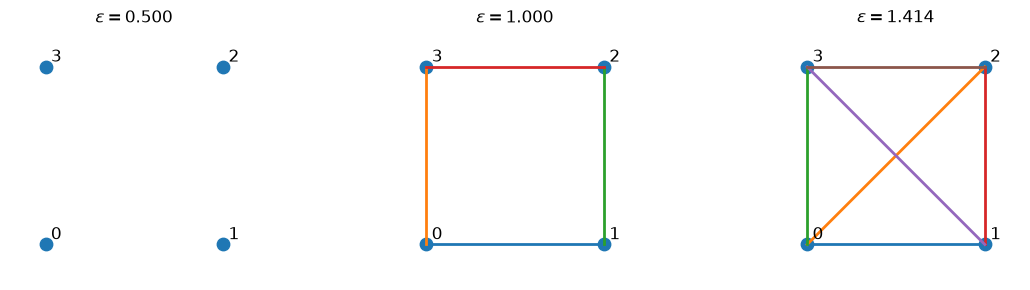

In [6]:
import numpy as np

square = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0]
])

distance_matrix = np.linalg.norm(
    square[:, None, :] - square[None, :, :],
    axis=2
)

scales = [0.5, 1.0, np.sqrt(2)]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, epsilon in zip(axes, scales):
    for i in range(len(square)):
        for j in range(i + 1, len(square)):
            if distance_matrix[i, j] <= epsilon:
                ax.plot(
                    [square[i, 0], square[j, 0]],
                    [square[i, 1], square[j, 1]],
                    linewidth=2
                )

    ax.scatter(square[:, 0], square[:, 1], s=80)

    for i, (x, y) in enumerate(square):
        ax.text(x + 0.03, y + 0.03, str(i), fontsize=12)

    ax.set_title(rf"$\varepsilon={epsilon:.3f}$")
    ax.set_aspect("equal")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.axis("off")

plt.tight_layout()
plt.show()

At

$$
\varepsilon=1,
$$

the four edges form a cycle, so the 1-skeleton has a 1-dimensional hole.

At

$$
\varepsilon=\sqrt{2},
$$

the diagonals appear. In the full Vietoris–Rips complex, the corresponding triangles also appear, so the previous cycle can become filled.

This is precisely the kind of topological evolution that persistent homology tracks.

## 11. Constructing a small Vietoris–Rips filtration

For a finite point cloud, we can implement the Vietoris–Rips construction directly for a small example.

A simplex

$$
\sigma=\{x_{i_0},\ldots,x_{i_k}\}
$$

appears at the scale

$$
f(\sigma)
=
\max_{p,q\in\sigma} d(p,q).
$$

This number is the length of the longest edge of the simplex.

### Pseudocode

```text
FOR every nonempty subset sigma of the point cloud:
    compute the largest pairwise distance inside sigma
    assign that value as the filtration value of sigma

For a chosen epsilon:
    include sigma if its filtration value <= epsilon
```

In [7]:
from itertools import combinations


def vr_filtration(points):
    n = len(points)
    values = {}

    for r in range(1, n + 1):
        for simplex in combinations(range(n), r):
            if len(simplex) == 1:
                value = 0.0
            else:
                value = max(
                    np.linalg.norm(points[i] - points[j])
                    for i, j in combinations(simplex, 2)
                )

            values[simplex] = value

    return values


vr_values = vr_filtration(square)

for simplex, value in sorted(
    vr_values.items(),
    key=lambda item: (item[1], len(item[0]), item[0])
):
    print(simplex, "->", round(value, 3))

(0,) -> 0.0
(1,) -> 0.0
(2,) -> 0.0
(3,) -> 0.0
(0, 1) -> 1.0
(0, 3) -> 1.0
(1, 2) -> 1.0
(2, 3) -> 1.0
(0, 2) -> 1.414
(1, 3) -> 1.414
(0, 1, 2) -> 1.414
(0, 1, 3) -> 1.414
(0, 2, 3) -> 1.414
(1, 2, 3) -> 1.414
(0, 1, 2, 3) -> 1.414


This is a small implementation, intentionally written for understanding rather than efficiency.

For a dataset with many points, enumerating every subset is computationally expensive. Specialized implementations will become important when we work with realistic point clouds.

## 12. Visualizing the filtration at different scales

A useful picture is to show the same point cloud at several thresholds.

The following visualization displays the 1-skeleton of the Vietoris–Rips filtration. The mathematical filtration contains higher-dimensional simplices too; we are suppressing those here so that the geometry remains visible.

### Pseudocode

```text
Compute the filtration value of every simplex.

For each selected threshold epsilon:
    display every edge whose filtration value is <= epsilon

Arrange the stages side by side.
```

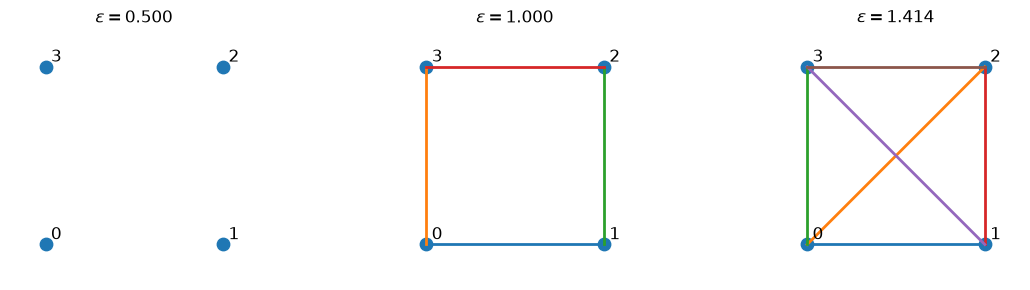

In [8]:
square_scales = [0.5, 1.0, np.sqrt(2)]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, epsilon in zip(axes, square_scales):
    for simplex, value in vr_values.items():
        if len(simplex) == 2 and value <= epsilon:
            i, j = simplex
            ax.plot(
                [square[i, 0], square[j, 0]],
                [square[i, 1], square[j, 1]],
                linewidth=2
            )

    ax.scatter(square[:, 0], square[:, 1], s=80)

    for i, (x, y) in enumerate(square):
        ax.text(x + 0.03, y + 0.03, str(i), fontsize=12)

    ax.set_title(rf"$\varepsilon={epsilon:.3f}$")
    ax.set_aspect("equal")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13. A conceptual picture

It is useful to keep the following hierarchy in mind:

$$
\boxed{\text{data}}
\longrightarrow
\boxed{\text{metric}}
\longrightarrow
\boxed{\text{simplicial complexes}}
\longrightarrow
\boxed{\text{filtration}}
\longrightarrow
\boxed{\text{persistent homology}}.
$$

The first four notebooks have now developed the first four stages.

- **Metric spaces** tell us what it means for data points to be close.
- **Simplicial complexes** turn collections of points and relations into topological spaces.
- **Homology** tells us about holes in a fixed complex.
- **Filtrations** let us study a whole family of complexes at different scales.

The next notebook will ask:

> How can we summarize the birth and death of homological features across an entire filtration?

## 14. Filtration versus persistent homology

It is worth keeping these two concepts separate.

A **filtration** is the geometric/combinatorial object:

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m.
$$

**Persistent homology** is an algebraic analysis of this object:

$$
H_k(K_0)\to H_k(K_1)\to\cdots\to H_k(K_m).
$$

So persistent homology does not replace the filtration.

Rather:

> **The filtration is the input; persistent homology analyzes how topology evolves along it.**

## 15. Summary

In this notebook we learned that:

1. A filtration is a nested sequence

   $$
   K_0\subseteq K_1\subseteq\cdots\subseteq K_m.
   $$

2. Simplices can be assigned filtration values describing when they appear.

3. A valid filtration must preserve the simplicial-complex condition.

4. A function on simplices gives a filtration when faces appear no later than the simplices containing them.

5. A vertex function can induce a lower-star filtration via

   $$
   f(\sigma)=\max_{v\in\sigma}g(v).
   $$

6. A metric space naturally gives a Vietoris–Rips filtration.

7. Filtrations allow us to watch homological features appear and disappear.

The next step is persistent homology.

## Exercises

### Exercise 1 — Build a filtration

Let

$$
K=\{0,1,2,01,12,02,012\}.
$$

Assign filtration values so that:

- all vertices appear first;
- the three edges appear one at a time;
- the triangle appears last.

Write down the resulting filtration explicitly.

### Exercise 2 — Find a non-filtration

Construct three simplicial complexes

$$
K_0,K_1,K_2
$$

such that each is individually a simplicial complex, but the sequence is not a filtration.

Explain exactly where nesting fails.

### Exercise 3 — Lower-star filtration

Let a triangle have vertex values

$$
g(0)=3,\qquad g(1)=1,\qquad g(2)=4.
$$

Compute the filtration value of every simplex using

$$
f(\sigma)=\max_{v\in\sigma}g(v).
$$

### Exercise 4 — Vietoris–Rips

For three points on a line,

$$
x_0=0,\qquad x_1=1,\qquad x_2=3,
$$

compute the filtration value of every nonempty simplex in the Vietoris–Rips construction.

At what scale does the edge $02$ appear?

At what scale does the triangle $012$ appear?

### Exercise 5 — Draw the movie

Take four points arranged in a square and draw the Vietoris–Rips 1-skeleton at three different scales.

Then explain which topological feature is present at the intermediate scale.

### Exercise 6 — Think ahead

Suppose a 1-dimensional hole appears at parameter $t=2$ and disappears at parameter $t=5$.

What information about this feature would you want a summary of persistent homology to retain?

Do not worry about the formal answer yet. This is the motivation for the next notebook.

## References

1. H. Edelsbrunner and J. Harer, *Computational Topology: An Introduction*, American Mathematical Society, 2010.

2. F. Chazal and B. Michel, “An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists,” *Frontiers in Artificial Intelligence* 4 (2021), 667963.  
   DOI: https://doi.org/10.3389/frai.2021.667963

3. G. Carlsson, “Topology and Data,” *Bulletin of the American Mathematical Society* 46 (2009), 255–308.